## 2. Plotting the dynamic sea level

This note plots dynamic sea level aggregated data. [Additionally we load a table and group the result by average melting in 2100, 2200 and 2300 and and melt parameterization.]

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
sns.set_context("paper")
sns.set_style("whitegrid")

computed_dir = '/Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/ComputedScalars'
computed_dir_helene = '/Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/ComputedScalarsHelene'
figures_dir = '/Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/figures'


In [2]:
# Get: Group, Model, Experiment, Climate forcing, Model setup, fileID, Main submission, Melt parameterisation, Melt parameters
df = pd.read_csv('../Metadata.txt', usecols=[1,2,3,4,5,6,7,8,9])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0

# Define constants for conversion
rhow= 1028
oceanarea = 361e6*1000**2 # m2 

# Set time var for all data
time=np.arange(2015,2300) # common start/end time
i_2100= np.argwhere(time == 2099)[0][0]
i_2200= np.argwhere(time == 2199)[0][0]
i_2300= np.argwhere(time == 2299)[0][0]

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

In [3]:
# function to make all timeseries same start & end date
def subset_all(time,data):
    i2016 = np.argwhere(time == 2016)[0][0]
    i2299 = np.argwhere(time == 2299)[0][0]
    timenew = time[i2016:i2299+1]
    datanew = data[i2016:i2299+1]
    return timenew, datanew

## Get the DSLC, anomaly wrt control
Output the data into the dictionary dic_dslc and dic_dslctime

In [158]:
# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

# Loop to populate dictionary with dslc data from all models and experiments
dic_dslc = {}
dic_dslc_wais = {}
dic_dslc_eais = {}
dic_dslc_ap = {}
dic_dslc_secs = [{} for _ in range(18)]

dic_dslctime = {}
for iexp, expname in enumerate(expnames):
    # create new dictionary for each experiment; key is model
    dic_all = {}
    dic_wais = {}
    dic_eais = {}
    dic_ap = {}
    dic_alltime = {}
    dic_secs = [{} for _ in range(18)]

    file_exp = os.listdir(f"{computed_dir}/{expname}/dslc_anom")
    file_exp = [file for file in file_exp if len(file) >= 3]

    # remove some files if less than 3 datasets in experiment
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    # dictionary referenced by model run name
    for ifile in range(len(file_exp)):
        filename = f"{computed_dir}/{expname}/dslc_anom/{file_exp[ifile]}"
        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]

        # convert Gt to mm water equiv gmsl
        d = xr.open_dataset(filename,decode_times=False )
        data_all = -1 * d.dslc_anom.values*1e12/rhow/oceanarea # all Antarctica
        data_wais = -1 * d.dslc_anom_region_1.values*1e12/rhow/oceanarea # just WAIS
        data_eais = -1 * d.dslc_anom_region_2.values*1e12/rhow/oceanarea # just EAIS
        data_ap = -1 * d.dslc_anom_region_3.values*1e12/rhow/oceanarea # just Ant Peninsula
        time = d.time.values
        
        data_secs = [None] * 18

        # fill the empty list with all the sectors
        for i_sec in range(18):
            data_secs[i_sec] = -1 * d['dslc_anom_sector_' + str(i_sec+1)].values * 1e12 / rhow / oceanarea
        
        # check: are dslc and time variables same length?
        if len(data_all) != len(time):
            print('Error: dslc \n')
            print(filename)
            break

        # subset so all datasets are same length
        time,data_all = subset_all(time,data_all)
        time,data_wais = subset_all(time,data_wais)
        time,data_eais = subset_all(time,data_eais)
        time,data_ap = subset_all(time,data_ap)
        
        for i_sec in range(18):
            time, data_secs[i_sec] = subset_all(time, data_secs[i_sec])
        
        dic_all[modelrun] = data_all
        dic_wais[modelrun] = data_wais
        dic_eais[modelrun] = data_eais
        dic_ap[modelrun] = data_ap
        dic_alltime[modelrun] = time

        for i_sec in range(18):
            dic_secs[i_sec][modelrun] = data_secs[i_sec]

        # remove some datasets if file list for each is not complete
        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            if len(data_all) > 250:
                valuesend_dict[expname].append(data_all[time.size-1])
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2100'] = data_all[i_2100-5:i_2100+5].mean()
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2200'] = data_all[i_2200-5:i_2200+5].mean()
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2300'] = data_all[i_2300-5:i_2300].mean()

            else:
               print("Error: " + df['Experiment'] + " is too short. Excluding from file list")

    # save all data from each experiment as sub-dictionary
    dic_dslc[expname]=dic_all
    dic_dslc_wais[expname]=dic_wais
    dic_dslc_eais[expname]=dic_eais
    dic_dslc_ap[expname]=dic_ap
    dic_dslctime[expname]=dic_alltime
    
    for i_sec in range(18):
        dic_dslc_secs[i_sec][expname] = dic_secs[i_sec]


## Get the BMB, anomaly with respect to control
Output the data to the dictionaries dic_bmb and dic_bmbtime

In [26]:
# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
dic_bmb = {}
dic_bmb_wais = {}
dic_bmb_eais = {}
dic_bmb_ap = {}
dic_bmb_secs = [{} for _ in range(18)]
dic_bmbtime = {}

# also calculate the cumulative BMB
dic_bmb_cum = {}
dic_bmb_cum_wais = {}
dic_bmb_cum_eais = {}
dic_bmb_cum_ap = {}
dic_bmb_cum_secs = [{} for _ in range(18)]

# Loop to populate dictionary with dslc data from all models and experiments
for iexp, expname in enumerate(expnames):
    # create new dictionary for each experiment; key is model
    dic_all = {}
    dic_alltime = {}
    dic_wais = {}
    dic_eais = {}
    dic_ap = {}
    dic_secs = [{} for _ in range(18)]

    # cumulative bmb
    dic_cum_all = {}
    dic_cum_wais = {}
    dic_cum_eais = {}
    dic_cum_ap = {}
    dic_cum_secs = [{} for _ in range(18)]

    file_exp = os.listdir(f"{computed_dir}/{expname}/Aggregated_BMB_anom")
    file_exp = [file for file in file_exp if len(file) >= 3]

    # remove some files if less than 3 datasets in experiment
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    # dictionary referenced by model run name
    for ifile in range(len(file_exp)):
        filename = f"{computed_dir}/{expname}/Aggregated_BMB_anom/{file_exp[ifile]}"
        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]
 
        # melt data positive if melting; negative if refreeze
        d = xr.open_dataset(filename,decode_times=False )
        data_all = -1 * d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12 # all Antarctica
        data_wais = -1 * d.shelfmelt_region_1.values * 365.25 * 24 * 3600 / 10**12 # WAIS
        data_eais = -1 * d.shelfmelt_region_2.values * 365.25 * 24 * 3600 / 10**12 # EAIS
        data_ap = -1 * d.shelfmelt_region_3.values * 365.25 * 24 * 3600 / 10**12 # Ant Penin
        time = d.time.values
        
        # another empty list to fill the time series
        data_secs = [None] * 18

        # fill the empty list with all the sectors
        for i_sec in range(18):
            data_secs[i_sec] = d['shelfmelt_sector_' + str(i_sec+1)].values
        
        # subset so all datasets are same length
        time,data_all  = subset_all(time,data_all)
        time,data_wais = subset_all(time,data_wais)
        time,data_eais = subset_all(time,data_eais)
        time,data_ap   = subset_all(time,data_ap)
        
        for i_sec in range(18):
            time, data_secs[i_sec] = subset_all(time, data_secs[i_sec])
        
        dic_all[modelrun]  = data_all
        dic_wais[modelrun] = data_wais
        dic_eais[modelrun] = data_eais
        dic_ap[modelrun]   = data_ap
        dic_alltime[modelrun] = time
        
        dic_cum_all[modelrun]  = np.nancumsum(data_all)
        dic_cum_wais[modelrun] = np.nancumsum(data_wais)
        dic_cum_eais[modelrun] = np.nancumsum(data_eais)
        dic_cum_ap[modelrun]   = np.nancumsum(data_ap)
        
        # add the data to the relevant dictionaries
        for i_sec in range(18):
            dic_secs[i_sec][modelrun] = data_secs[i_sec]
            dic_cum_secs[i_sec][modelrun] = np.nancumsum(data_secs[i_sec])

        # remove some datasets if file list for each is not complete
        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            if len(data_all) > 250:

                # make sure melt data correct sign (if model centre output differed in sign to convention)
                if data_all[-1] > 0:
                    data_all = -data_all
                    data_wais= -data_wais
                    data_eais= -data_eais
                    data_ap  = -data_ap

                if -np.sum(data_all[:285]) > 4 * 10**6 or -np.sum(data_all[:285]) < 0:
                    print("Error: something is wrong with data from " + filename)
                else:
                    valuesend_dict[expname].append(data_all[time.size-1])
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = data_all[i_2100-5:i_2100+5].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = data_all[i_2200-5:i_2200+5].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = data_all[i_2300-5:i_2300].mean()
      
            else:
                print("Error: " + df['Experiment'] + " is too short. Excluding from file list")

    # save all data from each experiment as sub-dictionary
    dic_bmb[expname] = dic_all
    dic_bmb_wais[expname] = dic_wais
    dic_bmb_eais[expname] = dic_eais
    dic_bmb_ap[expname] = dic_ap
    dic_bmbtime[expname] = dic_alltime

    dic_bmb_cum[expname] = dic_cum_all
    dic_bmb_cum_wais[expname] = dic_cum_wais
    dic_bmb_cum_eais[expname] = dic_cum_eais
    dic_bmb_cum_ap[expname] = dic_cum_ap
        
    for i_sec in range(18):
        dic_bmb_secs[i_sec][expname] = dic_secs[i_sec]
        dic_bmb_cum_secs[i_sec][expname] = dic_cum_secs[i_sec]

Error: something is wrong with data from /Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/ComputedScalars/expAE02/Aggregated_BMB_anom/shelfmelt_AIS_IMAU_UFEMISM1_expAE02_anom.nc
Error: something is wrong with data from /Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/ComputedScalars/expAE03/Aggregated_BMB_anom/shelfmelt_AIS_IMAU_UFEMISM1_expAE03_anom.nc
Error: something is wrong with data from /Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/ComputedScalars/expAE03/Aggregated_BMB_anom/shelfmelt_AIS_VUB_AISMPALEO_expAE03_anom.nc
Error: something is wrong with data from /Users/fmcc0003/issm/projects/mnt/ncihome/ismip6_hackathon/ComputedScalars/expAE05/Aggregated_BMB_anom/shelfmelt_AIS_IMAU_UFEMISM1_expAE05_anom.nc


## Get the shelf melt at the grounding line
Output the data to the dictionaries dic_glmelt and dic_glmelttime


### DO WE HAVE COMPLETE LIST OF GL MELT DATA??

In [6]:
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
dic_glmelt = {}
dic_glmelttime = {}
fnames_include = 'computed_groundingline_bmb'
lfnames_include = len(fnames_include)

# Loop to populate dictionary with dslc data from all models and experiments
for iexp, expname in enumerate(expnames):
    # create new dictionary for each experiment; key is model
    dic_data = {}
    dic_datatime = {}
    file_exp = os.listdir(f"{computed_dir}/{expname}/groundingline")
    file_exp = [file for file in file_exp if len(file) >= 3 and file[:lfnames_include].__eq__(fnames_include)]

    # remove some files if less than 3 datasets in experiment
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    # dictionary referenced by model run name
    for ifile in range(len(file_exp)):
        filename = f"{computed_dir}/{expname}/groundingline/{file_exp[ifile]}"
        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]
 
        # melt data positive if melting; negative if refreeze
        d = xr.open_dataset(filename,use_cftime=True )
        data = -1 * d.groundingline_bmb_antarctica.values * 365.25 * 24 * 3600 / 10**12
        time = d["time.year"].to_numpy()
        
        # subset so all datasets are same length
        time,data = subset_all(time,data)
        dic_data[modelrun] = data
        dic_datatime[modelrun] = time

        # remove some datasets if file list for each is not complete
        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            if len(data) > 250:

                # make sure melt data correct sign (if model centre output differed in sign to convention)
                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print("Error: something is wrong with data from " + filename)
                else:
                    valuesend_dict[expname].append(data[time.size-1])
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = data[i_2100-5:i_2100+5].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = data[i_2200-5:i_2200+5].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = data[i_2300-5:i_2300].mean()
      
            else:
                print("Error: " + df['Experiment'] + " is too short. Excluding from file list")
                
        # save all data from each experiment as sub-dictionary
        dic_glmelt[expname] = dic_data
        dic_glmelttime[expname] = dic_datatime

# Plotting

## 1 Plot the dynamic sea level contribution as a function of time

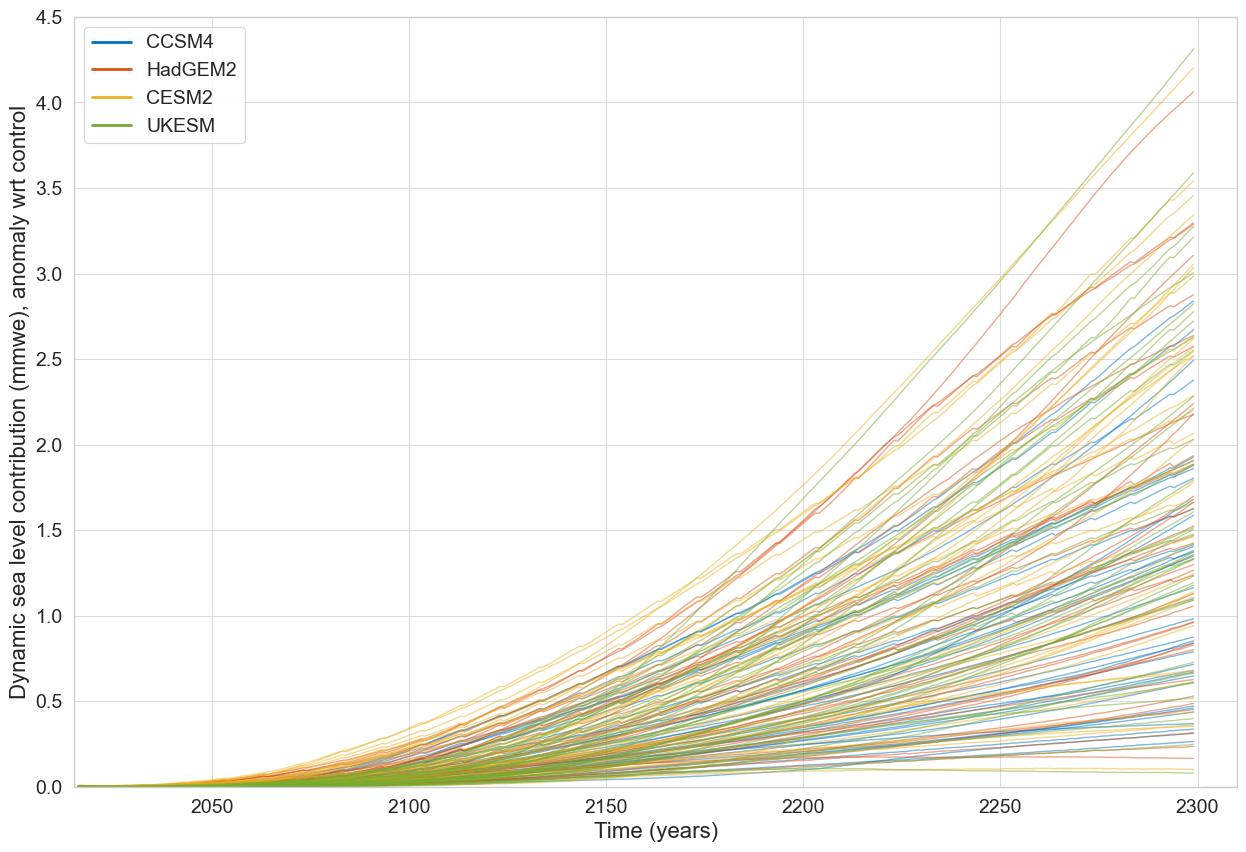

In [7]:
f,ax = plt.subplots(1,1, figsize = (15,10))

## TODO: ADD THE MEAN OF THE CLIMATE FORCING TO THE PLOT; MAY BE BUG IN DATA LENGTH
for iexp, expname in enumerate(dic_dslc):
    climate_forcing = dic_dslc[expname]
    climate_time = dic_dslctime[expname]
    dslcmean = 0
    for cgcm in climate_forcing:
        plt.plot(climate_time[cgcm], climate_forcing[cgcm], linewidth=1, color=colors[iexp, :], alpha=0.5)
        #print(climate_forcing[cgcm].shape)
        #dslcmean += climate_forcing[cgcm]
    #dslcmean = dslcmean / len(climate_forcing)
    #plt.plot(climate_time[cgcm], dslcmean, linewidth=1, color=colors[iexp, :])
    
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

ax.set_ylim([0, 4.5])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Dynamic sea level contribution (mmwe), anomaly wrt control', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

ax.set_xlim([2015, 2310])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
plt.savefig(figures_dir + '/dslc_anom_2300.pdf', format='pdf', bbox_inches='tight')
plt.show()



## 2 Plot BMB vs DSLC (all climate scenarios)

All models and melt rate parameterisations

/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_28312/518789284.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(melt[modelrun],dslc[modelrun],s=1,c=colors[iexp, :])


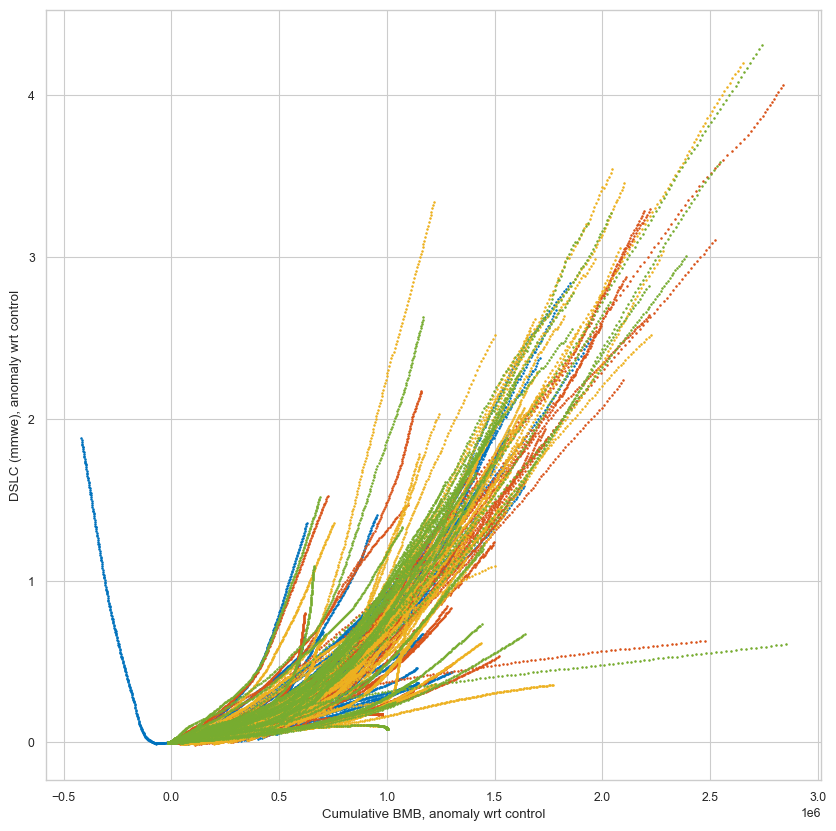

In [203]:
f,ax = plt.subplots(1,1, figsize = (10,10))
colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

for iexp, expname in enumerate(expnames):
    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['fileID'].unique()
    
    dslc = dic_dslc[expname]
    melt = dic_bmb_cum[expname]

    for i, modelrun in enumerate(unique_entries):
        modelkey = (df_climateforcing.loc[(df_climateforcing['fileID']==modelrun),'Model']).item()
        if modelrun in dslc.keys():
            #ax[iexp].scatter(melt[ism],dslc[ism],s=1,c=modelcolor[modelkey[1]])
            ax.scatter(melt[modelrun],dslc[modelrun],s=1,c=colors[iexp, :])
            ax.set_ylabel('DSLC (mmwe), anomaly wrt control')
            ax.set_xlabel('Cumulative BMB, anomaly wrt control')
        #ax[iexp].legend(modelcolor.keys(), frameon = True,bbox_to_anchor=[1.2, 0.5],labelcolor=colors)

#ax[0].set_title(expnames[0],fontsize=14)
#ax[1].set_title(expnames[1],fontsize=14)
#ax[2].set_title(expnames[2],fontsize=14)
#ax[3].set_title(expnames[3],fontsize=14)

## 3 Plot BMB vs DSLC (all climate scenarios)

Separate out by experiment

Text(0.5, 1.0, 'expAE05')

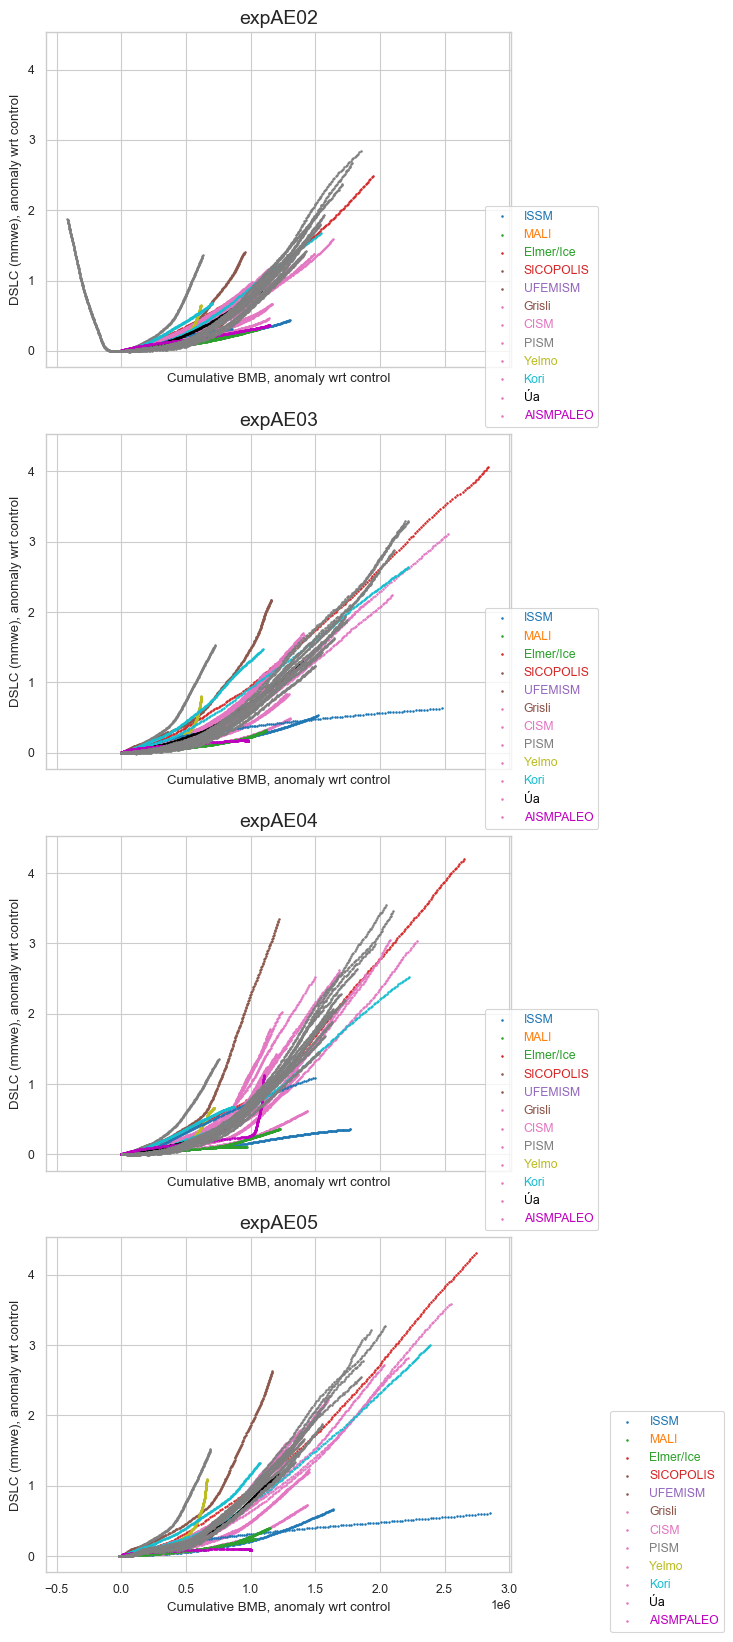

In [198]:
f,ax = plt.subplots(4,1, figsize = (6,20), sharey = True,sharex =True)

modelcolor = {}
for i, name in enumerate(df['Model'].unique()):
    modelcolor[name] = colors[i]
    
for iexp, expname in enumerate(expnames):
    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['fileID'].unique()
    
    dslc = dic_dslc[expname]
    melt = dic_bmb_cum[expname]

    for i, modelrun in enumerate(unique_entries):
        modelkey = (df_climateforcing.loc[(df_climateforcing['fileID']==modelrun),'Model']).item()
        if modelrun in dslc.keys():
            #ax[iexp].scatter(melt[ism],dslc[ism],s=1,c=modelcolor[modelkey[1]])
            ax[iexp].scatter(melt[modelrun],dslc[modelrun],s=1,c=modelcolor[modelkey])
            ax[iexp].set_ylabel('DSLC (mmwe), anomaly wrt control')
            ax[iexp].set_xlabel('Cumulative BMB, anomaly wrt control')
        ax[iexp].legend(modelcolor.keys(), frameon = True,bbox_to_anchor=[1.2, 0.5],labelcolor=colors)

ax[0].set_title(expnames[0],fontsize=14)
ax[1].set_title(expnames[1],fontsize=14)
ax[2].set_title(expnames[2],fontsize=14)
ax[3].set_title(expnames[3],fontsize=14)

## Plot BMB vs DSLC

Compare the cumulative BMB against DSLC (both datasets are anomalies wrt control), for different melt rate parameterisations and ice sheet models.

TODO / NEED TO FIX: 
- Something is wrong with the colours / legend labelling in the below plots?? I think it's skipping some keys
- One of hte PISM (?) linear melt rate param runs is incorrect (wrong sign). Need to check that the sign is being correctly applied in the BMB calculation above
- whichever model is the dark pink line (AISMPALEO??) there is some very strange behaviours, particularly for EAIS. 

Text(0.5, 1.0, 'expAE05')

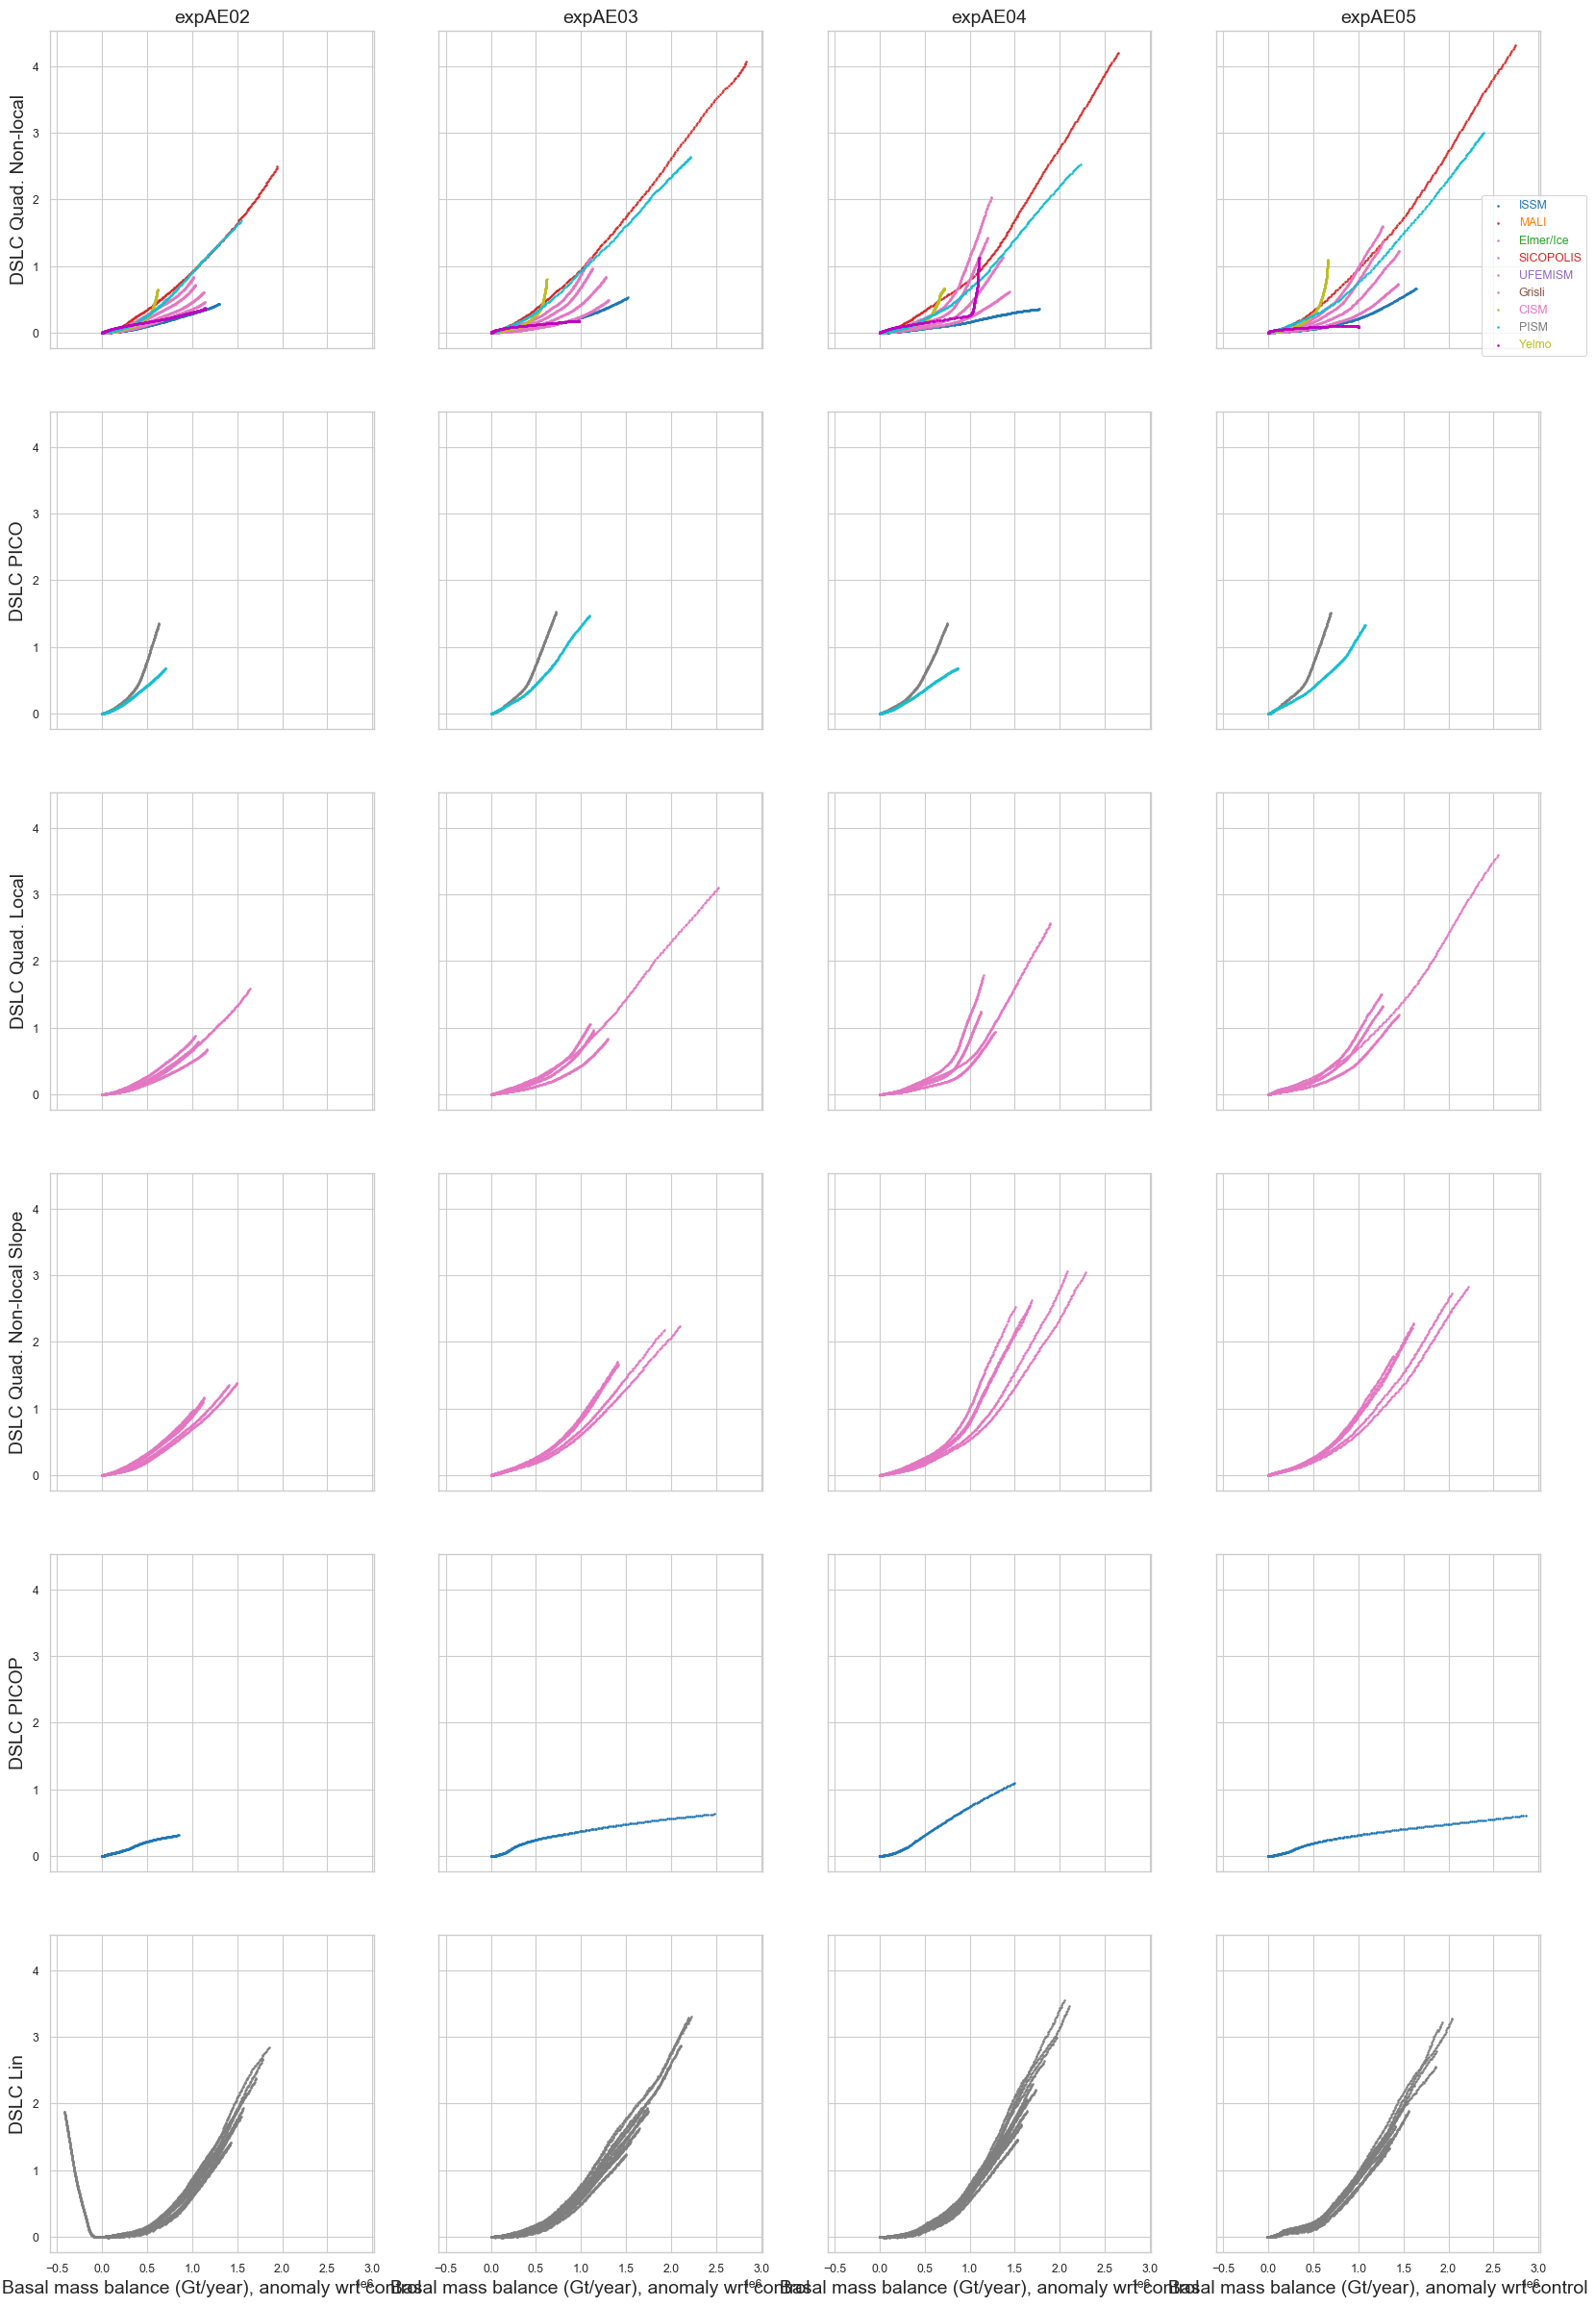

In [152]:
f,ax = plt.subplots(6, 4, figsize = (20,30), sharey = True,sharex =True)
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'k', 'm']
modelcolor = {}
for i, name in enumerate(df['Model'].unique()):
    modelcolor[name] = colors[i]

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dslc = dic_dslc[expname]
    melt = dic_bmb_cum[expname]

    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt parameterisation'].unique()
    
    for i, meltparam in enumerate(unique_entries):
        modelrun = df_climateforcing.loc[(df_climateforcing['Melt parameterisation']==meltparam),'fileID']
        for j in range(len(modelrun)):
            mname = modelrun.values[j]
            for text in df['Model'].unique():
                if text in mname:
                    if mname in dslc.keys():
                        ax[i,iexp].scatter(melt[mname], dslc[mname], s=1, c=modelcolor[text])
                        #ax[i,iexp].scatter(melt[mname], dslc[mname], s=1, label=mname, c=modelcolor[text])
        
        ax[i,0].set_ylabel('DSLC '+ meltparam,fontsize=14)
        ax[-1,iexp].set_xlabel('Basal mass balance (Gt/year), anomaly wrt control',fontsize=14)

ax[0,-1].legend(modelcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

#ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title(expnames[0],fontsize=14)
ax[0,1].set_title(expnames[1],fontsize=14)
ax[0,2].set_title(expnames[2],fontsize=14)
ax[0,3].set_title(expnames[3],fontsize=14)

## West Antarctica

TODO: Something is wrong with the colours / legend labelling in the below plots?? I think it's skipping some keys. NEED TO FIX


Text(0.5, 1.0, 'expAE05')

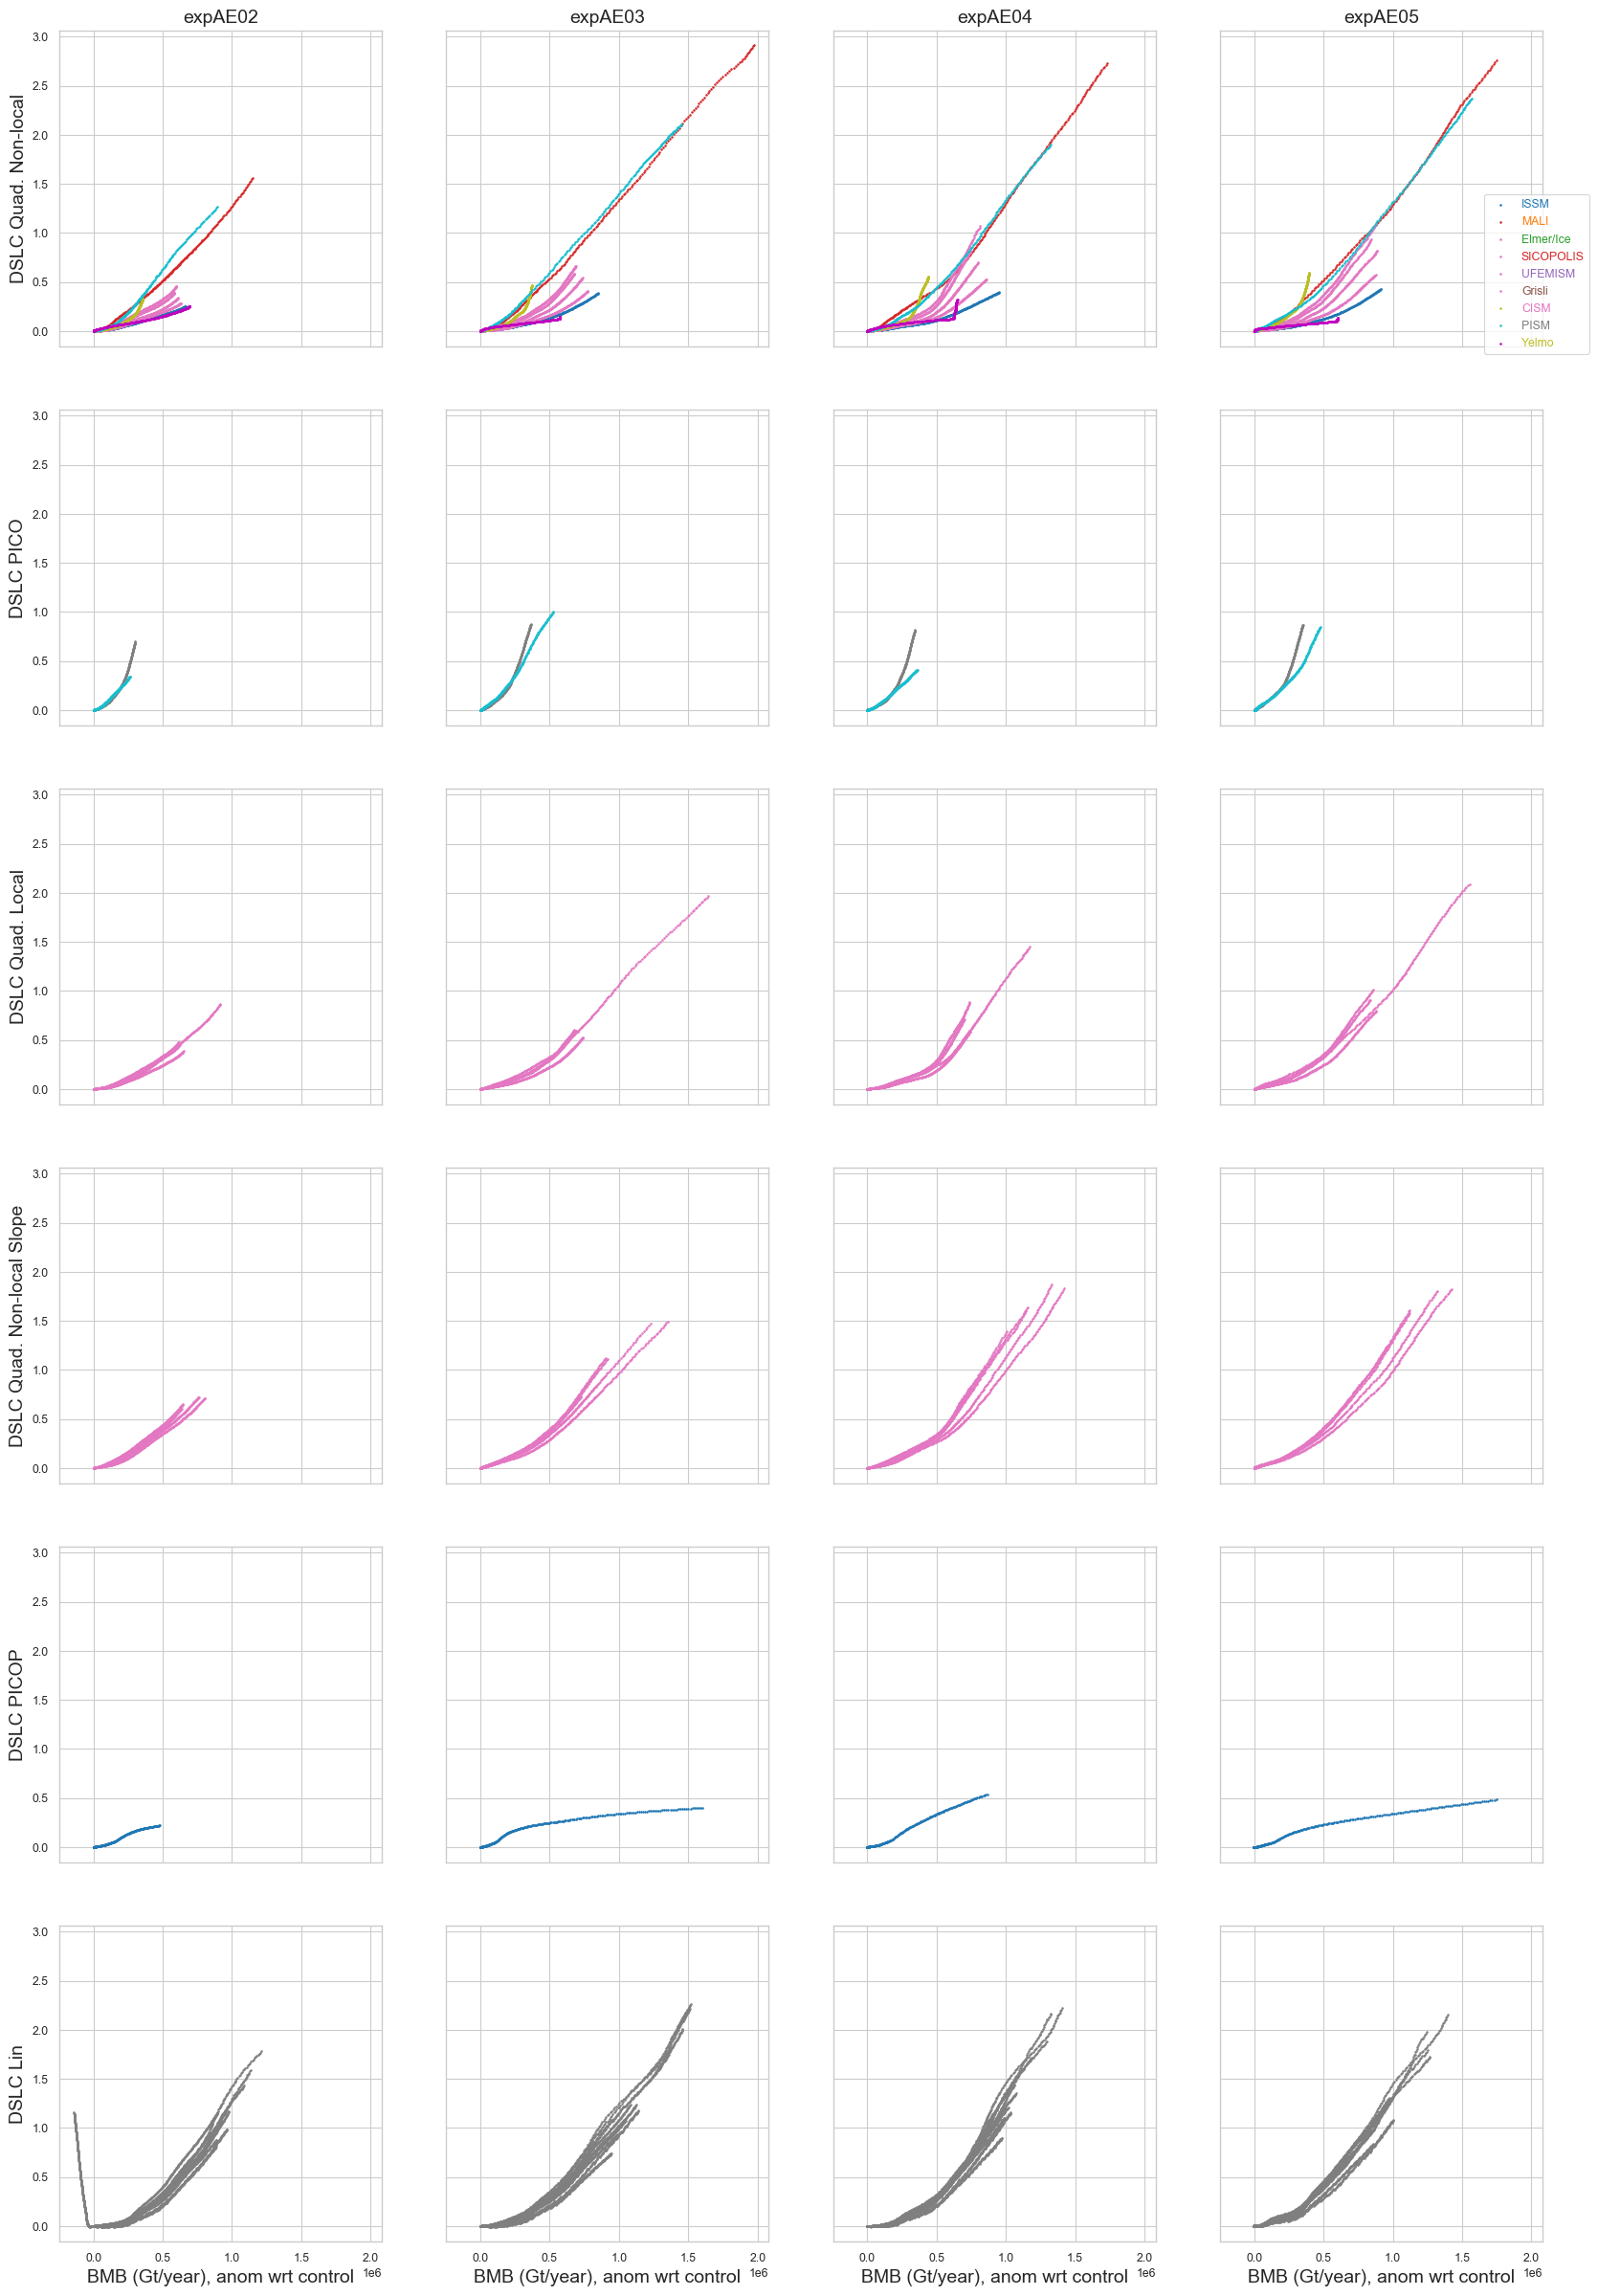

In [136]:
f,ax = plt.subplots(6, 4, figsize = (20,30), sharey = True,sharex =True)
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'k', 'm']
modelcolor = {}
for i, name in enumerate(df['Model'].unique()):
    modelcolor[name] = colors[i]

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dslc = dic_dslc_wais[expname]
    melt = dic_bmb_cum_wais[expname]

    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt parameterisation'].unique()
    
    for i, meltparam in enumerate(unique_entries):
        modelrun = df_climateforcing.loc[(df_climateforcing['Melt parameterisation']==meltparam),'fileID']
        for j in range(len(modelrun)):
            mname = modelrun.values[j]
            for text in df['Model'].unique():
                if text in mname:
                    if mname in dslc.keys():
                        ax[i,iexp].scatter(melt[mname], dslc[mname], s=1, c=modelcolor[text])
                        #ax[i,iexp].scatter(melt[mname], dslc[mname], s=1, label=mname, c=modelcolor[text])
        
        ax[i,0].set_ylabel('DSLC '+ meltparam,fontsize=14)
        ax[-1,iexp].set_xlabel('BMB (Gt/year), anom wrt control',fontsize=14)

ax[0,-1].legend(modelcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

#ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title(expnames[0],fontsize=14)
ax[0,1].set_title(expnames[1],fontsize=14)
ax[0,2].set_title(expnames[2],fontsize=14)
ax[0,3].set_title(expnames[3],fontsize=14)

## East Antarctica

TODO: Something is wrong with the colours / legend labelling in the below plots?? I think it's skipping some keys. NEED TO FIX

Text(0.5, 1.0, 'expAE05')

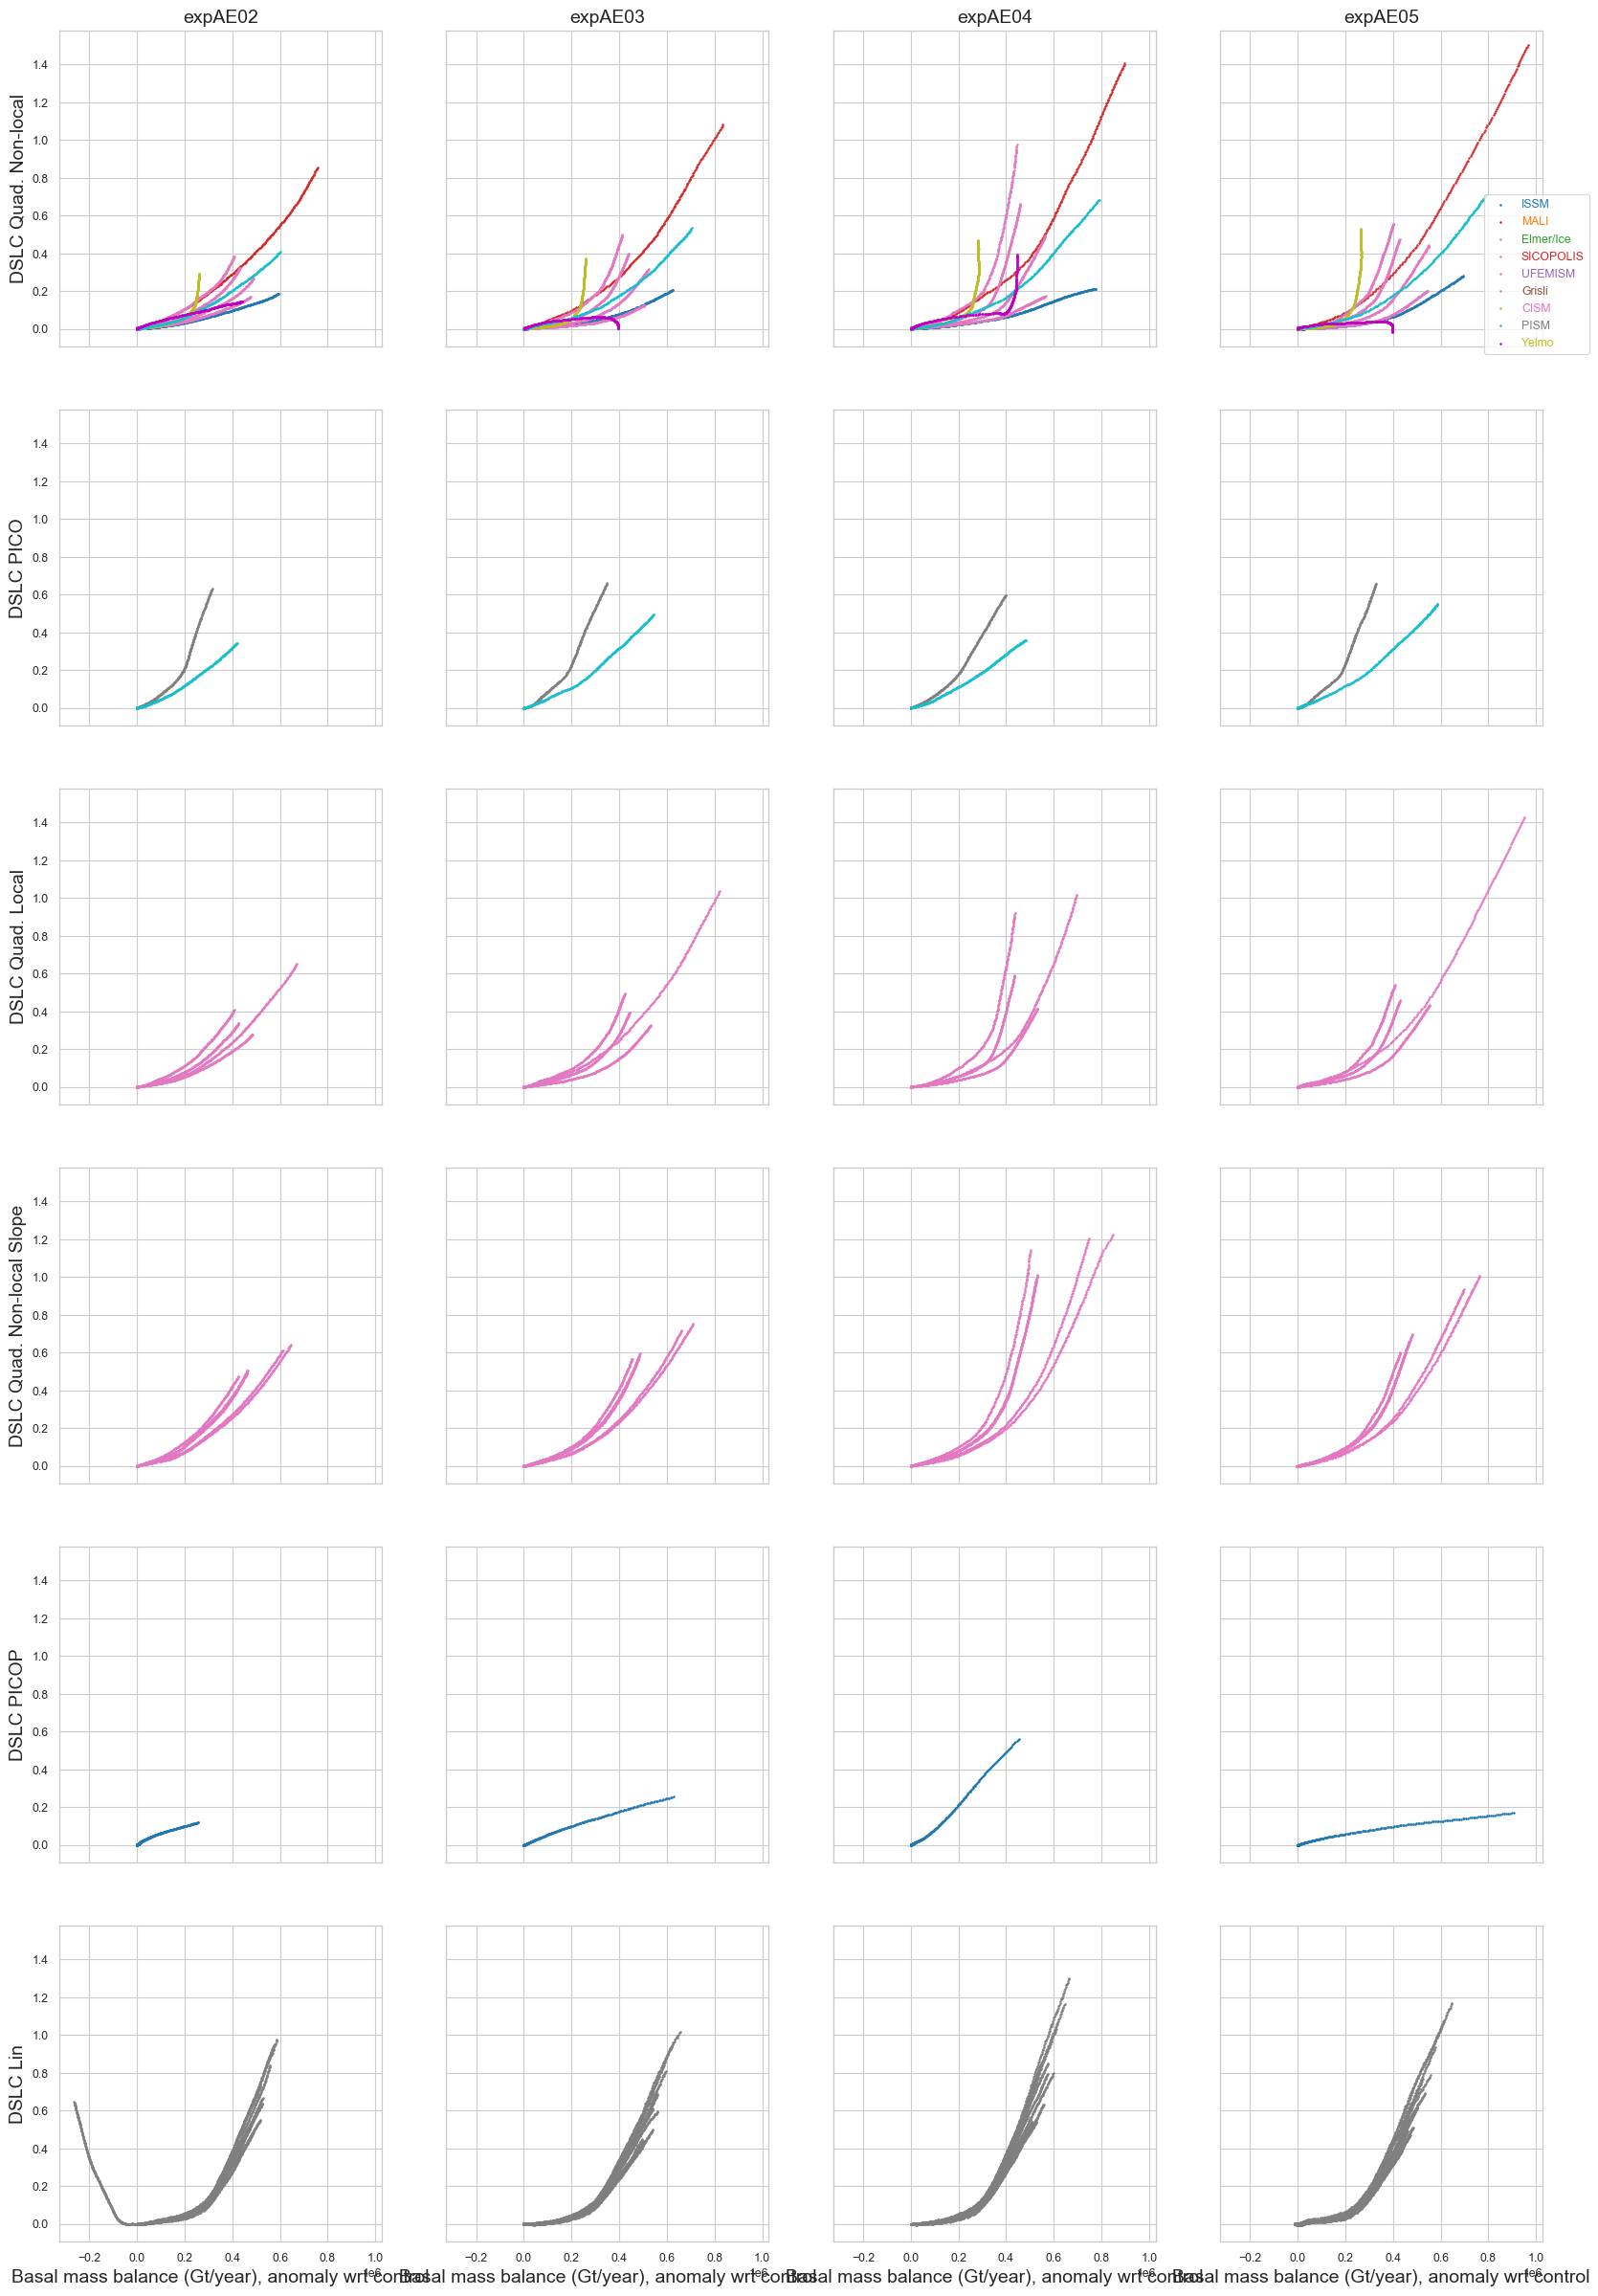

In [135]:
f,ax = plt.subplots(6, 4, figsize = (20,30), sharey = True,sharex =True)
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'k', 'm']
modelcolor = {}
for i, name in enumerate(df['Model'].unique()):
    modelcolor[name] = colors[i]

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dslc = dic_dslc_eais[expname]
    melt = dic_bmb_cum_eais[expname]

    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt parameterisation'].unique()
    
    for i, meltparam in enumerate(unique_entries):
        modelrun = df_climateforcing.loc[(df_climateforcing['Melt parameterisation']==meltparam),'fileID']
        for j in range(len(modelrun)):
            mname = modelrun.values[j]
            for text in df['Model'].unique():
                if text in mname:
                    if mname in dslc.keys():
                        ax[i,iexp].scatter(melt[mname], dslc[mname], s=1, c=modelcolor[text])
                        #ax[i,iexp].scatter(melt[mname], dslc[mname], s=1, label=mname, c=modelcolor[text])
        
        ax[i,0].set_ylabel('DSLC '+ meltparam,fontsize=14)
        ax[-1,iexp].set_xlabel('Basal mass balance (Gt/year), anomaly wrt control',fontsize=14)

ax[0,-1].legend(modelcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

#ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title(expnames[0],fontsize=14)
ax[0,1].set_title(expnames[1],fontsize=14)
ax[0,2].set_title(expnames[2],fontsize=14)
ax[0,3].set_title(expnames[3],fontsize=14)

## Sectors where the GL runs away

This occurs for sectors 2, 4, and 5 (in the Amundsen Sea sector, Siple Coast, and Weddell Sea in the Ronne sector)

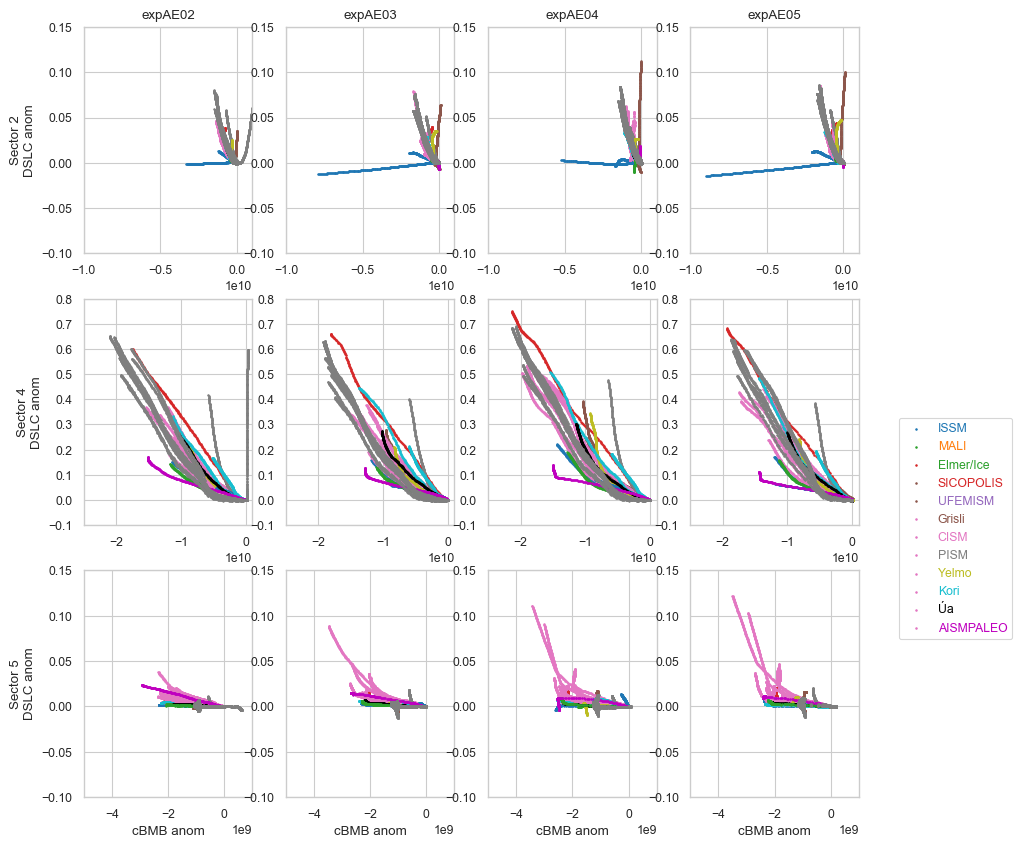

In [197]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'k', 'm']
sectors = [2, 4, 5]
modelcolor = {}
xmin = [-1.0e10, -2.5e10, -0.5e10]
xmax = [0.1e10, 0.1e10, 0.1e10]
ymin = [-0.1, -0.1, -0.1]
ymax = [0.15, 0.8, 0.15]

# plot by sector and by experiment
f,ax = plt.subplots(3,4, figsize=(10,10), sharey=False, sharex=False)

modelcolor = {}
for i, name in enumerate(df['Model'].unique()):
    modelcolor[name] = colors[i]
    
for isec in range(3):
    secnum = sectors[isec]

    for iexp, expname in enumerate(expnames):
        df_climateforcing = df[(df['Experiment'] == expname)]
        unique_entries = df_climateforcing['fileID'].unique()
        dslc = dic_dslc_secs[secnum][expname]
        melt = dic_bmb_cum_secs[secnum][expname]

        for i, modelrun in enumerate(unique_entries):
            modelkey = (df_climateforcing.loc[(df_climateforcing['fileID']==modelrun),'Model']).item()
            if modelrun in dslc.keys():
                #ax[iexp].scatter(melt[ism],dslc[ism],s=1,c=modelcolor[modelkey[1]])
                ax[isec,iexp].scatter(melt[modelrun],dslc[modelrun],s=1,c=modelcolor[modelkey])
                ax[isec,iexp].set_xlim([xmin[isec], xmax[isec]])
                ax[isec,iexp].set_ylim([ymin[isec], ymax[isec]])
ax[1,-1].legend(modelcolor.keys(), frameon = True,bbox_to_anchor=[1.2, 0.5],labelcolor=colors)
            
for i in range(3):
    ax[i,0].set_ylabel('Sector ' + str(sectors[i]) + '\nDSLC anom')
for i in range(4):
    ax[-1,i].set_xlabel('cBMB anom')
    ax[0,i].set_title(expnames[i])


In [178]:
expnames

['expAE02', 'expAE03', 'expAE04', 'expAE05']

In [194]:
xmin[2]

-5000000000.0